# Rachel Clusters — Training Results Analysis

Analyzes the ResNet-50 model trained on 15,141 building clusters from Rachel's dataset.
Binary classification: Farm vs NotFarm.

**Run this notebook on a pod with the network volume mounted.**

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, HTML

ROOT = Path("/workspace/farm-mapping")
OUTPUT = ROOT / "data" / "output" / "rachel_clusters"
PATCHES_DIR = ROOT / "data" / "patches"
SPLITS_PATH = PATCHES_DIR / "splits" / "rachel_clusters.csv"
CANDIDATES_DIR = ROOT / "data" / "rachel_geometry_candidates" / "candidates"
PARQUET_PATH = ROOT / "data" / "rachel_geometry_candidates" / "selected_clusters_relabeled.parquet"

# Load scored candidates
scored = pd.read_parquet(OUTPUT / "scored_candidates.parquet")
print(f"Scored candidates: {len(scored)}")
print(f"Columns: {list(scored.columns)}")
scored.head(3)

Scored candidates: 15130
Columns: ['candidate_id', 'lat', 'lng', 'predicted_score', 'predicted_label', 'confidence_tier', 'true_label', 'source', 'country', 'split', 'geometry']


,candidate_id,lat,lng,predicted_score,predicted_label,confidence_tier,true_label,source,country,split,geometry
0,BRA_cluster_1039,-27.593813,-54.332705,0.984872,1,high,1,rachel_clusters,Brazil,train,b'\x01\x01\x00\x00\x00\xfcQ\x02\x16\x96*K\xc0\...
1,BRA_cluster_10325,-22.305995,-49.009477,0.097050,0,very_low,0,rachel_clusters,Brazil,train,b'\x01\x01\x00\x00\x00?\xe2\x12\x876\x81H\xc0\...
2,BRA_cluster_10356,-22.045597,-49.031385,0.970714,1,high,1,rachel_clusters,Brazil,train,b'\x01\x01\x00\x00\x00T\xc7\x03i\x04\x84H\xc0\...


In [57]:
scored["country"].unique()

<ArrowStringArray>
['Brazil', 'Chile', 'Mexico', 'Thailand', 'United States']
Length: 5, dtype: str

In [48]:
# Load original Rachel data for extra columns
rachel = pd.read_parquet(PARQUET_PATH)
print(f"Original Rachel data: {len(rachel)} clusters")

# Load splits
if SPLITS_PATH.exists():
    splits = pd.read_csv(SPLITS_PATH)
    print(f"Split assignments: {len(splits)}")
    print(splits['split'].value_counts().to_dict())
else:
    splits = None
    print("No split assignments found")

Original Rachel data: 71322 clusters
Split assignments: 15130
{'train': 10594, 'val': 2268, 'test': 2268}


## 1. Overall Metrics

Prediction distribution:
pred_class
TP    11459
TN     2983
FP      536
FN      152



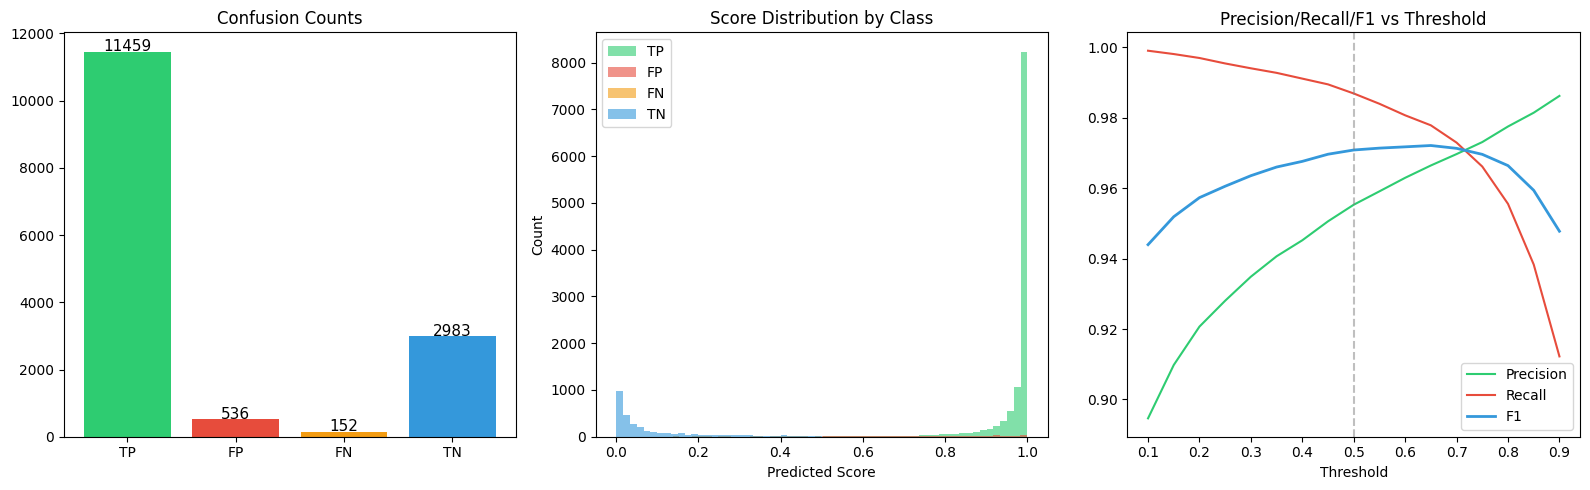

In [49]:
# Derive pred_class from predicted_label and true_label
scored["pred_class"] = "TN"
scored.loc[(scored["predicted_label"] == 1) & (scored["true_label"] == 1), "pred_class"] = "TP"
scored.loc[(scored["predicted_label"] == 1) & (scored["true_label"] == 0), "pred_class"] = "FP"
scored.loc[(scored["predicted_label"] == 0) & (scored["true_label"] == 1), "pred_class"] = "FN"

pred_classes = scored["pred_class"].value_counts()
print("Prediction distribution:")
print(pred_classes.to_string())
print()

COLORS = {"TP": "#2ecc71", "FP": "#e74c3c", "FN": "#f39c12", "TN": "#3498db"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion counts
counts = [pred_classes.get(k, 0) for k in ["TP", "FP", "FN", "TN"]]
axes[0].bar(["TP", "FP", "FN", "TN"], counts, color=[COLORS[k] for k in ["TP", "FP", "FN", "TN"]])
axes[0].set_title("Confusion Counts")
for i, v in enumerate(counts):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=11)

# Score distributions by class
for cls in ["TP", "FP", "FN", "TN"]:
    subset = scored[scored["pred_class"] == cls]
    if len(subset) > 0:
        axes[1].hist(subset["predicted_score"], bins=30, alpha=0.6, label=cls, color=COLORS[cls])
axes[1].set_xlabel("Predicted Score")
axes[1].set_ylabel("Count")
axes[1].set_title("Score Distribution by Class")
axes[1].legend()

# Precision-Recall by threshold
thresholds = np.arange(0.1, 0.95, 0.05)
precs, recs, f1s = [], [], []
for t in thresholds:
    pred = (scored["predicted_score"] >= t).astype(int)
    true = scored["true_label"].astype(int)
    tp = ((pred == 1) & (true == 1)).sum()
    fp = ((pred == 1) & (true == 0)).sum()
    fn = ((pred == 0) & (true == 1)).sum()
    p = tp / max(tp + fp, 1)
    r = tp / max(tp + fn, 1)
    f = 2 * p * r / max(p + r, 1e-8)
    precs.append(p); recs.append(r); f1s.append(f)
axes[2].plot(thresholds, precs, label="Precision", color="#2ecc71")
axes[2].plot(thresholds, recs, label="Recall", color="#e74c3c")
axes[2].plot(thresholds, f1s, label="F1", color="#3498db", linewidth=2)
axes[2].axvline(0.5, color="gray", linestyle="--", alpha=0.5)
axes[2].set_xlabel("Threshold")
axes[2].set_title("Precision/Recall/F1 vs Threshold")
axes[2].legend()

plt.tight_layout()
plt.show()

## 2. Results by Country

In [50]:
# Merge country info from candidates
cands = pd.concat([pd.read_csv(f) for f in sorted(CANDIDATES_DIR.glob("*.csv"))], ignore_index=True)
country_map = dict(zip(cands["id"].astype(str), cands["country"]))
scored["country"] = scored["candidate_id"].astype(str).map(country_map)

# Per-country metrics
rows = []
for country, grp in scored.groupby("country"):
    tp = (grp["pred_class"] == "TP").sum()
    fp = (grp["pred_class"] == "FP").sum()
    fn = (grp["pred_class"] == "FN").sum()
    tn = (grp["pred_class"] == "TN").sum()
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-8)
    rows.append({"Country": country, "N": len(grp), "TP": tp, "FP": fp, "FN": fn, "TN": tn,
                 "Precision": f"{prec:.3f}", "Recall": f"{rec:.3f}", "F1": f"{f1:.3f}"})

country_df = pd.DataFrame(rows).sort_values("N", ascending=False)
display(country_df)

,Country,N,TP,FP,FN,TN,Precision,Recall,F1
4,United States,10469,7878,221,38,2332,0.973,0.995,0.984
2,Mexico,2508,2175,97,44,192,0.957,0.980,0.969
3,Thailand,943,512,87,62,282,0.855,0.892,0.873
0,Brazil,705,461,99,3,142,0.823,0.994,0.900
1,Chile,505,433,32,5,35,0.931,0.989,0.959


## 3. Results by Farm Type (modified_label)

In [51]:
# Merge modified_label from Rachel parquet
rachel_labels = rachel.set_index("cluster_id")["modified_label"].to_dict()
scored["modified_label"] = scored["candidate_id"].astype(str).map(rachel_labels)

# Per-label metrics
label_rows = []
for label, grp in scored.groupby("modified_label"):
    if pd.isna(label): continue
    tp = (grp["pred_class"] == "TP").sum()
    fp = (grp["pred_class"] == "FP").sum()
    fn = (grp["pred_class"] == "FN").sum()
    tn = (grp["pred_class"] == "TN").sum()
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-8)
    label_rows.append({"Label": label, "N": len(grp), "TP": tp, "FP": fp, "FN": fn, "TN": tn,
                       "Precision": f"{prec:.3f}", "Recall": f"{rec:.3f}", "F1": f"{f1:.3f}"})

label_df = pd.DataFrame(label_rows).sort_values("N", ascending=False)
display(label_df)

,Label,N,TP,FP,FN,TN,Precision,Recall,F1
7,Farm: Poultry: Unspecified/Other,5942,5907,0,35,0,1.000,0.994,0.997
9,NotFarm,3519,0,536,0,2983,0.000,0.000,0.000
6,Farm: Poultry: Meat Chickens,2382,2338,0,44,0,1.000,0.982,0.991
3,Farm: Pigs,1994,1972,0,22,0,1.000,0.989,0.994
5,Farm: Poultry: Eggs,602,577,0,25,0,1.000,0.958,0.979
8,Farm: Unknown,343,331,0,12,0,1.000,0.965,0.982
0,Farm: Cattle,172,163,0,9,0,1.000,0.948,0.973
1,Farm: Mixed,87,84,0,3,0,1.000,0.966,0.982
4,Farm: PigsOrPoultry,71,70,0,1,0,1.000,0.986,0.993
2,Farm: Other,18,17,0,1,0,1.000,0.944,0.971


## 4. Template Score vs Model Score

Candidates with both scores: 15130


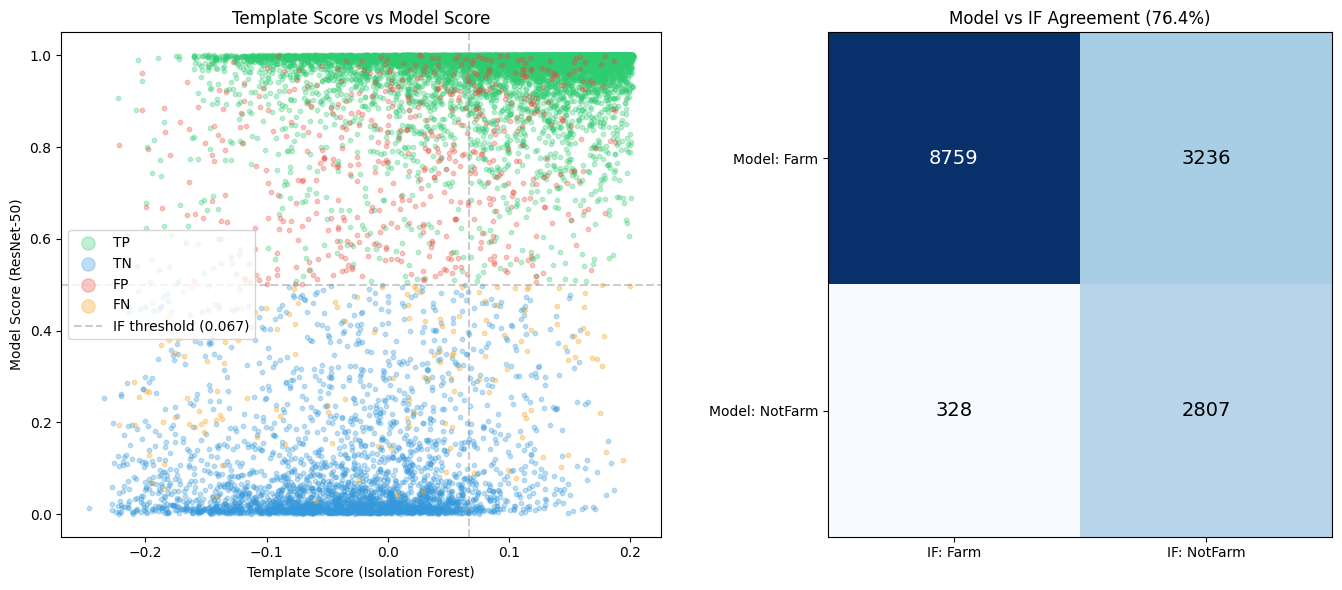

In [52]:
# Merge template_score_if from Rachel data
rachel_scores = rachel.set_index("cluster_id")["template_score_if"].to_dict()
scored["template_score_if"] = scored["candidate_id"].astype(str).map(rachel_scores)

has_both = scored[scored["template_score_if"].notna()].copy()
print(f"Candidates with both scores: {len(has_both)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: template score vs model score
for cls in ["TP", "TN", "FP", "FN"]:
    sub = has_both[has_both["pred_class"] == cls]
    axes[0].scatter(sub["template_score_if"], sub["predicted_score"],
                    alpha=0.3, s=10, label=cls, color=COLORS[cls])
axes[0].set_xlabel("Template Score (Isolation Forest)")
axes[0].set_ylabel("Model Score (ResNet-50)")
axes[0].set_title("Template Score vs Model Score")
axes[0].axhline(0.5, color="gray", linestyle="--", alpha=0.4)
axes[0].axvline(0.067, color="gray", linestyle="--", alpha=0.4, label="IF threshold (0.067)")
axes[0].legend(markerscale=3)

# Agreement between template threshold and model
has_both["if_positive"] = has_both["template_score_if"] >= 0.067
has_both["model_positive"] = has_both["predicted_score"] >= 0.5
agreement = (has_both["if_positive"] == has_both["model_positive"]).mean()

# Confusion between IF and model
both_pos = ((has_both["if_positive"]) & (has_both["model_positive"])).sum()
if_only = ((has_both["if_positive"]) & (~has_both["model_positive"])).sum()
model_only = ((~has_both["if_positive"]) & (has_both["model_positive"])).sum()
both_neg = ((~has_both["if_positive"]) & (~has_both["model_positive"])).sum()

conf = np.array([[both_pos, model_only], [if_only, both_neg]])
im = axes[1].imshow(conf, cmap="Blues")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["IF: Farm", "IF: NotFarm"])
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["Model: Farm", "Model: NotFarm"])
axes[1].set_title(f"Model vs IF Agreement ({agreement:.1%})")
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(conf[i, j]), ha="center", va="center", fontsize=14,
                     color="white" if conf[i, j] > conf.max() / 2 else "black")

plt.tight_layout()
plt.show()

## 5. Sample Patches — FP & FN Deep Dive

Matched patch_path: 15130 / 15130
FP: 536, FN: 152, TP: 11459


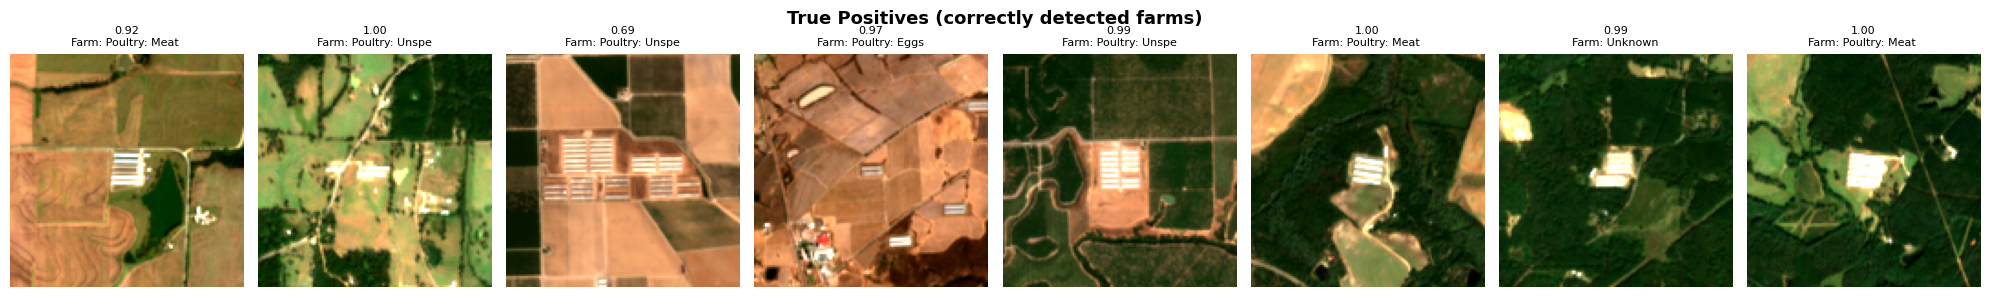

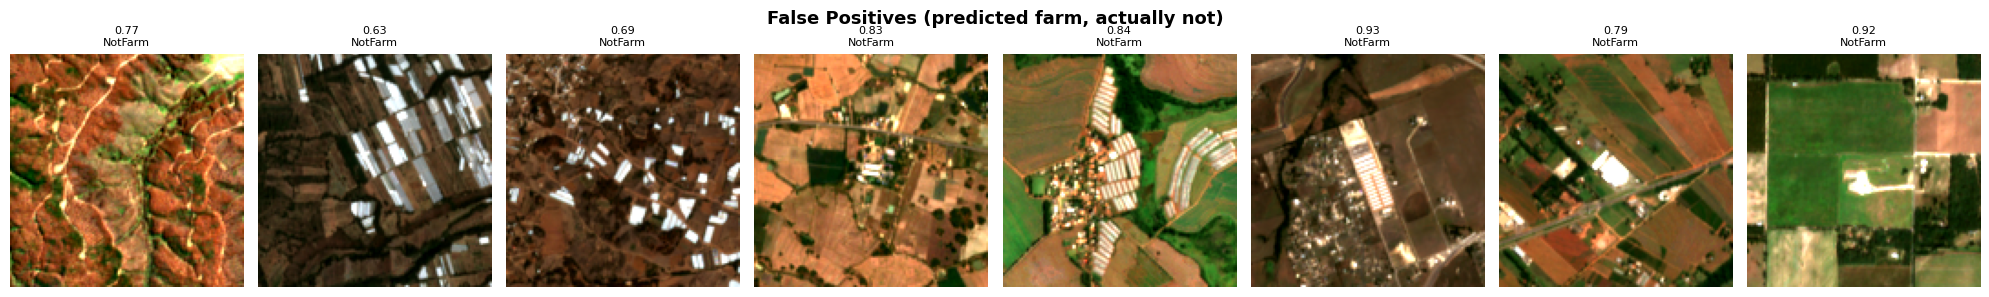

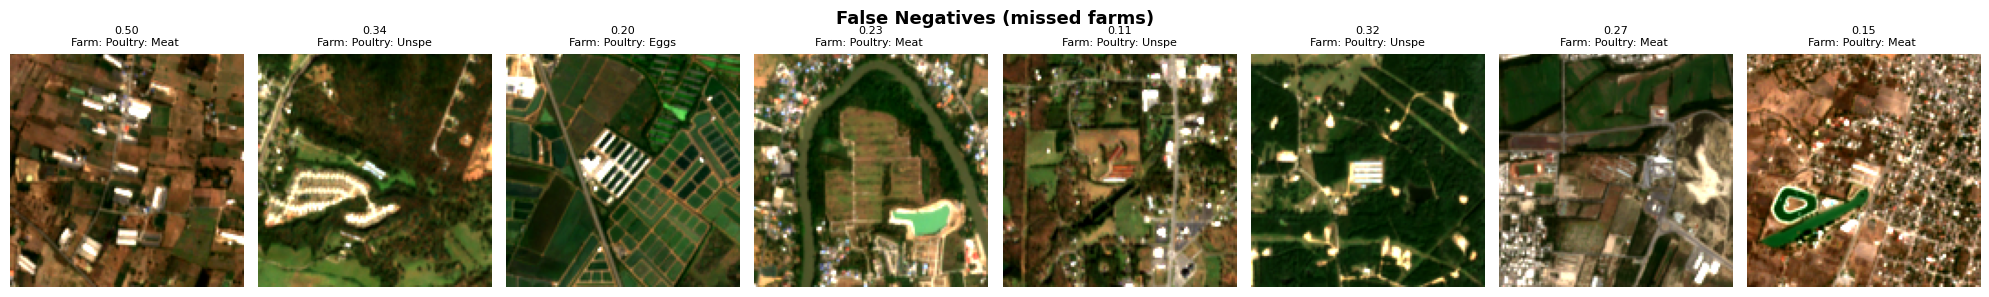

In [53]:
BAND_NAMES = ["B2", "B3", "B4", "B8", "B11", "B12", "NDVI", "NDBI", "NDWI"]
RGB_CH = [2, 1, 0]  # B4, B3, B2

# scored doesn't have patch_path — load from patch_meta.csv
meta = pd.read_csv(PATCHES_DIR / "patch_meta.csv", usecols=["candidate_id", "patch_path"])
patch_path_map = dict(zip(meta["candidate_id"].astype(str), meta["patch_path"]))
scored["patch_path"] = scored["candidate_id"].astype(str).map(patch_path_map)
print(f"Matched patch_path: {scored['patch_path'].notna().sum()} / {len(scored)}")

def load_patch(row):
    pp = row.get("patch_path", "")
    if not pp or pd.isna(pp):
        return None
    p = PATCHES_DIR / pp
    if not p.exists():
        return None
    return np.load(p)

def show_patches(subset, title, n=8):
    samples = subset[subset["patch_path"].notna()].sample(min(n, len(subset[subset["patch_path"].notna()])), random_state=42)
    fig, axes = plt.subplots(1, n, figsize=(2.5 * n, 3))
    if n == 1:
        axes = [axes]
    for i, (_, row) in enumerate(samples.iterrows()):
        if i >= n: break
        patch = load_patch(row)
        if patch is None:
            axes[i].text(0.5, 0.5, "No patch", ha="center")
            axes[i].axis("off")
            continue
        rgb = np.stack([patch[ch] for ch in RGB_CH], axis=-1)
        p2, p98 = np.percentile(rgb, [2, 98])
        rgb = np.clip((rgb - p2) / max(p98 - p2, 1), 0, 1)
        axes[i].imshow(rgb)
        label = row.get("modified_label", "")
        score = row.get("predicted_score", 0)
        axes[i].set_title(f"{score:.2f}\n{str(label)[:20]}", fontsize=8)
        axes[i].axis("off")
    for j in range(i + 1, n):
        axes[j].axis("off")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

fps = scored[scored["pred_class"] == "FP"]
fns = scored[scored["pred_class"] == "FN"]
tps = scored[scored["pred_class"] == "TP"]

print(f"FP: {len(fps)}, FN: {len(fns)}, TP: {len(tps)}")
show_patches(tps, "True Positives (correctly detected farms)")
show_patches(fps, "False Positives (predicted farm, actually not)")
show_patches(fns, "False Negatives (missed farms)")

## 6. FP/FN Google Maps Links

In [54]:
def make_gmaps_table(subset, title, n=20):
    top = subset.nlargest(n, "predicted_score") if title.startswith("FP") else subset.nsmallest(n, "predicted_score")
    rows_html = ""
    for _, row in top.iterrows():
        lat, lng = row.get("lat", 0), row.get("lng", 0)
        score = row.get("predicted_score", 0)
        cid = str(row.get("candidate_id", ""))[:25]
        label = str(row.get("modified_label", ""))[:30]
        country = str(row.get("country", ""))
        gmaps = f"https://www.google.com/maps/@{lat},{lng},500m/data=!3m1!1e3"
        rows_html += (
            f"<tr><td>{cid}</td><td>{score:.3f}</td><td>{label}</td>"
            f"<td>{country}</td><td>{lat:.4f}, {lng:.4f}</td>"
            f'<td><a href="{gmaps}" target="_blank">Map</a></td></tr>'
        )
    display(HTML(
        f"<h4>{title} (top {n})</h4>"
        "<table border='1' style='border-collapse:collapse; font-size:12px;'>"
        "<tr><th>ID</th><th>Score</th><th>Label</th><th>Country</th><th>Lat,Lng</th><th>Verify</th></tr>"
        f"{rows_html}</table>"
    ))

make_gmaps_table(fps, "FP — Highest confidence false positives")
make_gmaps_table(fns, "FN — Most confident misses")

ID,Score,Label,Country,"Lat,Lng",Verify
MEX_cluster_5905,1.000,NotFarm,Mexico,"19.7698, -103.5039",Map
USA_cluster_73722,0.999,NotFarm,United States,"32.1575, -82.5695",Map
USA_cluster_15854,0.999,NotFarm,United States,"41.2111, -96.9604",Map
CHL_cluster_1167,0.998,NotFarm,Chile,"-33.4539, -71.3930",Map
MEX_cluster_13080,0.998,NotFarm,Mexico,"21.3109, -100.5353",Map
USA_cluster_39842,0.998,NotFarm,United States,"33.9554, -91.9447",Map
USA_cluster_45042,0.998,NotFarm,United States,"35.1016, -84.7913",Map
USA_cluster_5022,0.998,NotFarm,United States,"36.7093, -119.3519",Map
USA_cluster_66656,0.995,NotFarm,United States,"35.0953, -86.0993",Map
CHL_cluster_2382,0.995,NotFarm,Chile,"-32.6515, -71.2033",Map


ID,Score,Label,Country,"Lat,Lng",Verify
THA_cluster_9100,0.029,Farm: Poultry: Eggs,Thailand,"14.8472, 101.6447",Map
USA_cluster_57630,0.037,Farm: Poultry: Unspecified/Oth,United States,"42.9263, -86.1546",Map
MEX_cluster_16236,0.043,Farm: Poultry: Eggs,Mexico,"25.3059, -100.0060",Map
USA_cluster_100002,0.048,Farm: Unknown,United States,"42.0932, -73.9482",Map
THA_cluster_7796,0.054,Farm: Unknown,Thailand,"13.6405, 101.0987",Map
THA_cluster_7811,0.067,Farm: Unknown,Thailand,"13.6438, 101.0978",Map
MEX_cluster_15767,0.073,Farm: Poultry: Eggs,Mexico,"26.0000, -100.5364",Map
USA_cluster_11143,0.080,Farm: Unknown,United States,"39.1909, -96.5242",Map
THA_cluster_21837,0.089,Farm: Poultry: Meat Chickens,Thailand,"15.1448, 104.8322",Map
USA_cluster_103532,0.091,Farm: Poultry: Unspecified/Oth,United States,"38.5035, -75.1180",Map


## 7. Cluster Morphology vs Predictions

Do cluster features (num_bldgs, total_area, building_density) correlate with correct predictions?

Candidates with morphology data: 15130


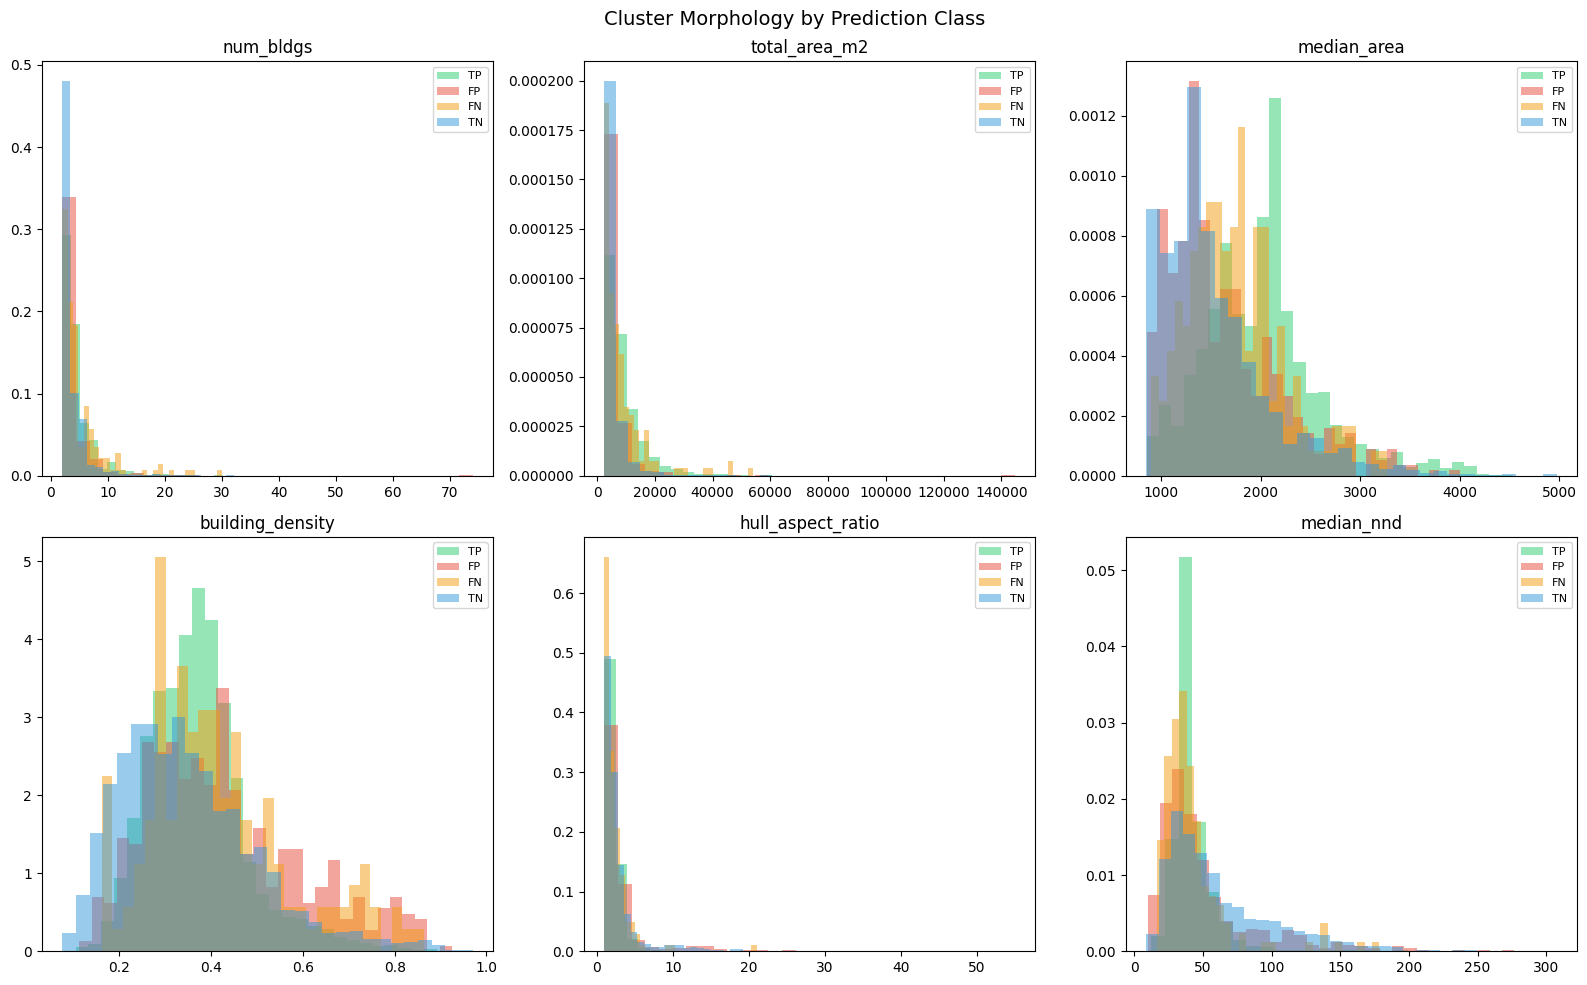

In [55]:
# Merge cluster morphology features
morph_cols = ["cluster_id", "num_bldgs", "total_area_m2", "median_area",
              "building_density", "hull_aspect_ratio", "median_nnd"]
morph = rachel[morph_cols].set_index("cluster_id")

scored_morph = scored.copy()
for col in morph_cols[1:]:
    scored_morph[col] = scored_morph["candidate_id"].astype(str).map(morph[col].to_dict())

has_morph = scored_morph[scored_morph["num_bldgs"].notna()].copy()
print(f"Candidates with morphology data: {len(has_morph)}")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features = ["num_bldgs", "total_area_m2", "median_area", "building_density", "hull_aspect_ratio", "median_nnd"]

for ax, feat in zip(axes.flat, features):
    for cls in ["TP", "FP", "FN", "TN"]:
        sub = has_morph[has_morph["pred_class"] == cls]
        if len(sub) == 0: continue
        vals = sub[feat].dropna()
        if len(vals) > 0:
            ax.hist(vals, bins=30, alpha=0.5, label=cls, color=COLORS[cls], density=True)
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.suptitle("Cluster Morphology by Prediction Class", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Train/Val/Test Split Analysis

In [56]:
if splits is not None:
    split_map = dict(zip(splits["candidate_id"].astype(str), splits["split"]))
    scored["split"] = scored["candidate_id"].astype(str).map(split_map)

    split_rows = []
    for split_name, grp in scored.groupby("split"):
        tp = (grp["pred_class"] == "TP").sum()
        fp = (grp["pred_class"] == "FP").sum()
        fn = (grp["pred_class"] == "FN").sum()
        tn = (grp["pred_class"] == "TN").sum()
        prec = tp / max(tp + fp, 1)
        rec = tp / max(tp + fn, 1)
        f1 = 2 * prec * rec / max(prec + rec, 1e-8)
        split_rows.append({"Split": split_name, "N": len(grp), "TP": tp, "FP": fp, "FN": fn, "TN": tn,
                           "Precision": f"{prec:.3f}", "Recall": f"{rec:.3f}", "F1": f"{f1:.3f}"})

    display(pd.DataFrame(split_rows))
else:
    print("No split assignments available")

,Split,N,TP,FP,FN,TN,Precision,Recall,F1
0,test,2268,1713,91,28,436,0.950,0.984,0.966
1,train,10594,8031,350,98,2115,0.958,0.988,0.973
2,val,2268,1715,95,26,432,0.948,0.985,0.966
